In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('test_scrape.csv')
X = df['description']

In [27]:
labels = df['game']

In [3]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r"\w+",
    stop_words=stopwords.words('english'),
    lowercase=True,
    min_df=5
)

tfidf_vectorizer.fit(X)
df_tfidf = pd.DataFrame.sparse.from_spmatrix(
    tfidf_vectorizer.transform(X),
    columns=tfidf_vectorizer.get_feature_names_out(),
)
df_tfidf

,0,00,000,01,08,1,10,100,1000,101,...,z,zealots,zeb,zero,zine,zombie,zombies,zone,zones,äventyrsspel
0,0.030107,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0.063981,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0.048597,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,0,0,0,0,0,0,0.012848,0,0,0,...,0,0,0,0,0,0,0,0,0,0
771,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
772,0,0,0,0,0,0,0.025741,0.037685,0,0,...,0,0,0,0,0,0,0,0,0,0
773,0.036449,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


PCA

In [35]:
from sklearn.decomposition import PCA

In [36]:
pca = PCA()
pca.fit(df_tfidf)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

548


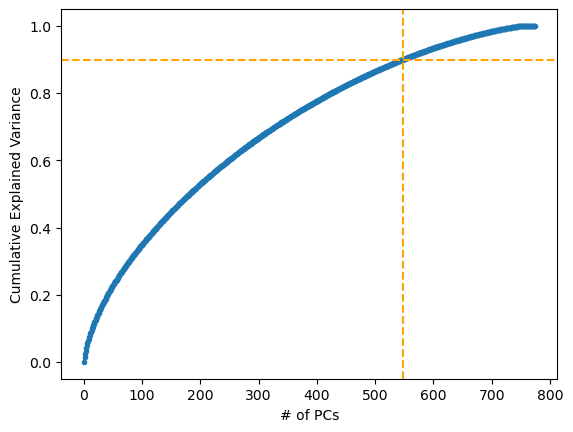

In [42]:
exp_var = [0]+list((pca.explained_variance_ratio_).cumsum())
retain = 0
plt.plot(range(0,775),exp_var, '.-')
plt.axhline(0.9, color='orange', linestyle='--')
plt.xlabel('# of PCs')
plt.ylabel('Cumulative Explained Variance')
for i in range(len(exp_var)):
    if exp_var[i]>=0.9:
        retain = i 
        plt.axvline(i, color='orange', linestyle='--');
        break

print(retain)

In [49]:
W = pd.DataFrame(pca.components_,
                 columns=df_tfidf.columns,
                 index=[f"PCA {i+1}" for i in range(len(pca.components_))])

X_transformed = pd.DataFrame((W @ df_tfidf.T).T)

# W = pca.components_
# W = pd.DataFrame(W, columns=df_tfidf.columns,
#                  index=[f'PCA {i + 1}' for i in range(df_tfidf.shape[1])])

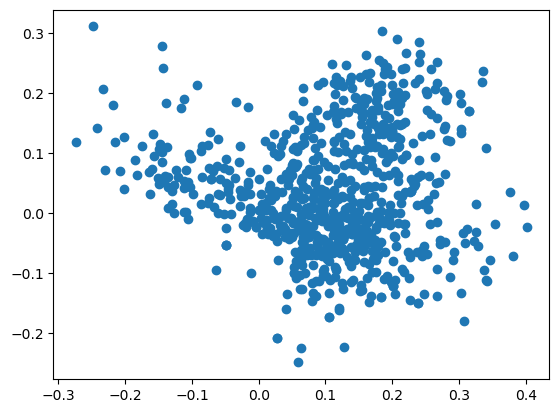

In [54]:
plt.scatter(X_transformed['PCA 1'], X_transformed['PCA 2'])

SVD

In [38]:
from sklearn.decomposition import TruncatedSVD

In [39]:
svd = TruncatedSVD(n_components=df_tfidf.shape[1])
svd.fit(df_tfidf)

,"n_components n_components: int, default=2Desired dimensionality of output data.If algorithm='arpack', must be strictly less than the number of features.If algorithm='randomized', must be less than or equal to the number of features.The default value is useful for visualisation. For LSA, a value of100 is recommended.",7100
,"algorithm algorithm: {'arpack', 'randomized'}, default='randomized'SVD solver to use. Either ""arpack"" for the ARPACK wrapper in SciPy(scipy.sparse.linalg.svds), or ""randomized"" for the randomizedalgorithm due to Halko (2009).",'randomized'
,"n_iter n_iter: int, default=5Number of iterations for randomized SVD solver. Not used by ARPACK. Thedefault is larger than the default in:func:`~sklearn.utils.extmath.randomized_svd` to handle sparsematrices that may have large slowly decaying spectrum.",5
,"n_oversamples n_oversamples: int, default=10Number of oversamples for randomized SVD solver. Not used by ARPACK.See :func:`~sklearn.utils.extmath.randomized_svd` for a completedescription... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD solver.Not used by ARPACK. See :func:`~sklearn.utils.extmath.randomized_svd`for more details... versionadded:: 1.1",'auto'
,"random_state random_state: int, RandomState instance or None, default=NoneUsed during randomized svd. Pass an int for reproducible results acrossmultiple function calls.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Tolerance for ARPACK. 0 means machine precision. Ignored by randomizedSVD solver.",0.0


In [7]:
energy = svd.singular_values_**2
energy_ratio = energy / energy.sum()
energy_ratio_cumsum = energy_ratio.cumsum()

In [8]:
from matplotlib import pyplot as plt

Explained variance at 538 SVs: 0.90


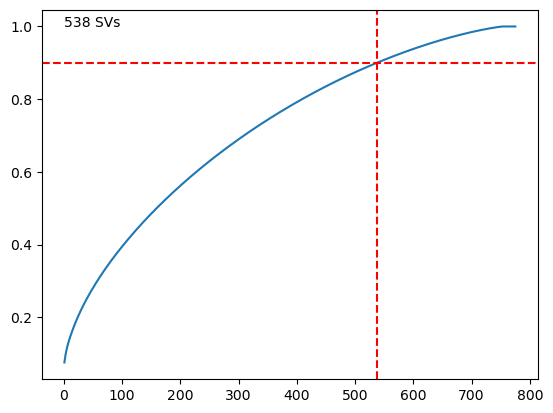

In [9]:
plt.plot([i for i in range(1,len(energy_ratio_cumsum)+1)], energy_ratio_cumsum)
plt.axhline(0.9, color='r', linestyle='--')

thresh = 0
for i in range(len(energy_ratio_cumsum)):
    if energy_ratio_cumsum[i] >= 0.9:
        plt.axvline(i+1, color='r', linestyle='--')
        plt.text(0, 1, f'{i+1} SVs')
        thresh = i+1
        print(f"Explained variance at {i+1} SVs: {energy_ratio_cumsum[i]:.2f}")
        break

In [10]:
W = pd.DataFrame(svd.components_, columns=df_tfidf.columns,
                 index=[f'SV {i+1}' for i in range(df_tfidf.shape[0])])
semantic_vectors = pd.DataFrame(svd.transform(df_tfidf), columns=W.index)

In [12]:
term_topic_matrix = pd.DataFrame(
    svd.components_.T,
    index=df_tfidf.columns,
    columns=[f'SV {i+1}' for i in range(df_tfidf.shape[0])]
)

In [15]:
def plot_topic_vector(term_topic_matrix, column, num_terms=20):
    """Return a plot of the weights of the topic vector with largest
    magnitude"""
    fig, ax = plt.subplots(figsize=(8, 6))
    (term_topic_matrix.loc[
        term_topic_matrix[column].abs().nlargest(num_terms).index[::-1], column
        ]
                      .plot(kind='barh'))

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel("Weight", fontsize=12)
    ax.set_ylabel("Term", fontsize=12)

    fig.suptitle(column, fontsize=14, weight='bold')
    
    return fig, ax

(<Figure size 800x600 with 1 Axes>, <Axes: xlabel='Weight', ylabel='Term'>)

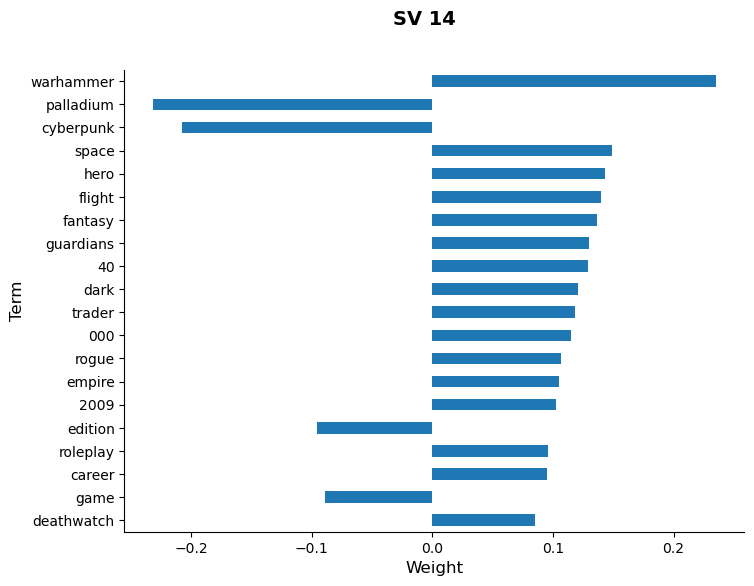

In [16]:
plot_topic_vector(term_topic_matrix, 'SV 14')

SV 9 - cyberpunk vs natural

In [17]:
from sklearn.cluster import KMeans

In [56]:
df_transformed = pd.DataFrame(pca.transform(df_tfidf), columns=W.index)
df_trunc = df_transformed.iloc[:, :thresh]

In [57]:
# Set number of trials
num_trials = 10
k_range = range(1, 21)

# Set results container - mean and std of inertias per trial
inertias_mean = []
inertias_std = []
for k in k_range:
    inertias = []
    for i in range(num_trials):
        # Fit and predict for k number of clusters setting
        cur_kmeans = KMeans(n_clusters=k, random_state=i, n_init='auto')
        cluster_labels = cur_kmeans.fit_predict(df_trunc)
        inertias.append(cur_kmeans.inertia_)
    inertias_mean.append(np.mean(inertias))
    inertias_std.append(np.std(inertias))
inertias_mean = np.array(inertias_mean)
inertias_std = np.array(inertias_std)

Text(0, 0.5, 'Inertia')

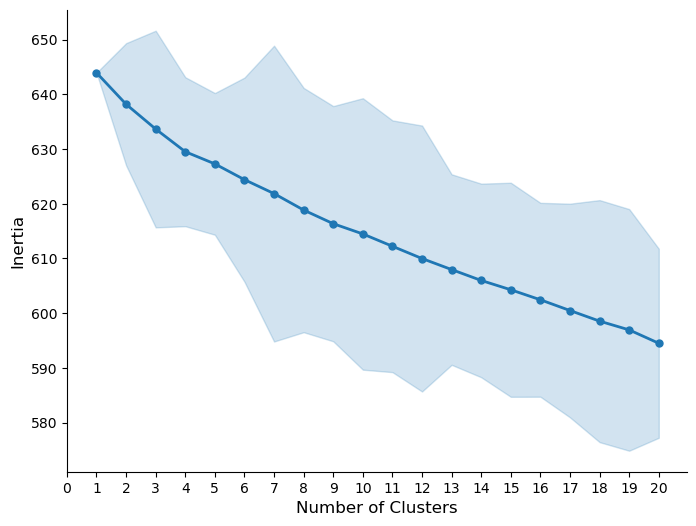

In [58]:
ebar_scale = 10
color='tab:blue'

fig, ax = plt.subplots(figsize=(8, 6))
ax.fill_between(
    k_range, inertias_mean + ebar_scale*inertias_std,
    inertias_mean - ebar_scale*inertias_std, alpha=0.2, color=color)
ax.plot(k_range, inertias_mean, 'o-', lw=2, ms=5, color=color)
ax.set_xticks(range(0, max(k_range) + 1))

ax.spines[['top', 'right']].set_visible(False)
ax.set_xlabel("Number of Clusters", fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)